In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

from src.generators import compute_required_nurses

ROOT = Path.cwd()
config = yaml.safe_load((ROOT / "data" / "assumptions.yaml").read_text())["nurse_staffing"]
master = pd.read_csv(ROOT / config["source_dataset"], parse_dates=["date"]).set_index("date")

categories = list(config["category_to_unit"])
census = master[[f"occupied_beds_{c}" for c in categories]]
census.columns = categories
census.shape

(2922, 9)

In [3]:
# Validation: date continuity, missing values, negatives, and section sum vs. total census
full_range = pd.date_range(master.index.min(), master.index.max(), freq="D")
section_sum = census.fillna(0).sum(axis=1)
validation = pd.Series({
    "rows": len(census),
    "missing_dates": len(full_range.difference(census.index)),
    "duplicate_dates": int(census.index.duplicated().sum()),
    "negative_values": int((census < 0).sum().sum()),
    "days_section_sum_ne_total": int((section_sum != master["total_occupied_beds"]).sum()),
    "days_over_capacity": int((master["total_occupied_beds"] > master["total_staffed_beds"]).sum()),
})
display(validation)
display(census.isna().sum().rename("missing_days").to_frame()
        .assign(first_non_missing=census.apply(lambda s: s.first_valid_index())))

rows                         2922
missing_dates                   0
duplicate_dates                 0
negative_values                 0
days_section_sum_ne_total       0
days_over_capacity              0
dtype: int64

,missing_days,first_non_missing
intensive,0,2017-01-01
delivery,0,2017-01-01
newborn,0,2017-01-01
non_elective_via_ed,0,2017-01-01
non_elective_other,0,2017-01-01
elective,0,2017-01-01
covid_19,1095,2020-01-01
influenza,0,2017-01-01
other_viral,0,2017-01-01


In [4]:
nurses = compute_required_nurses(
    census,
    config["category_to_unit"],
    config["unit_ratios"],
    config["shifts_per_day"],
)
nurses.insert(0, "total_occupied_beds", master["total_occupied_beds"])
display(nurses.describe().T[["mean", "min", "50%", "max"]].round(1))
nurses.groupby(nurses.index.year)[
    ["nurses_per_shift_min_total", "nurses_per_shift_max_total"]
].mean().round(1)

,mean,min,50%,max
total_occupied_beds,645.8,482.0,647.0,749.0
census_icu,84.3,52.0,85.0,120.0
nurses_per_shift_min_icu,42.4,26.0,43.0,60.0
nurses_per_shift_max_icu,84.3,52.0,85.0,120.0
census_med_surg,492.7,362.0,493.0,596.0
nurses_per_shift_min_med_surg,98.9,73.0,99.0,120.0
nurses_per_shift_max_med_surg,123.6,91.0,124.0,149.0
census_labor_delivery,40.1,13.0,40.0,65.0
nurses_per_shift_min_labor_delivery,20.3,7.0,20.0,33.0
nurses_per_shift_max_labor_delivery,40.1,13.0,40.0,65.0


,nurses_per_shift_min_total,nurses_per_shift_max_total
date,,
2017,168.4,260.2
2018,168.8,261.5
2019,173.0,268.4
2020,162.9,249.2
2021,171.7,261.7
2022,168.1,252.8
2023,169.8,253.8
2024,170.9,255.4


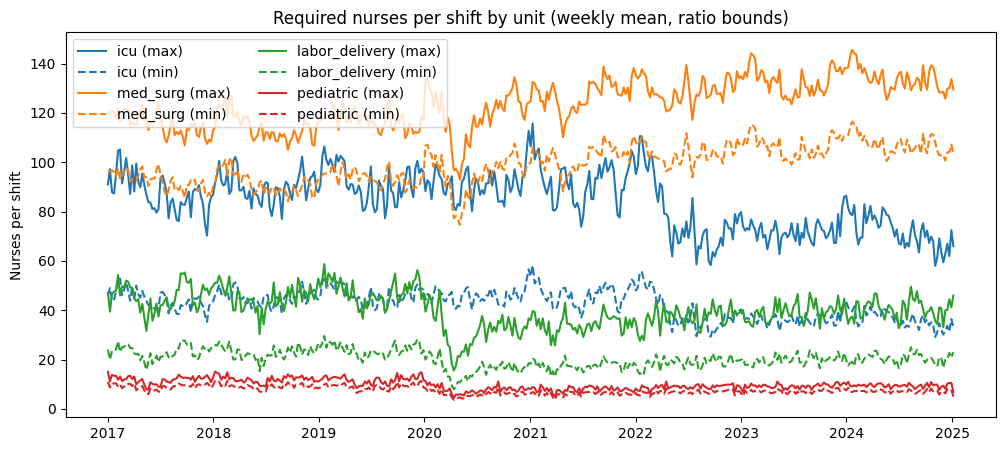

In [5]:
weekly = nurses.resample("W").mean()
fig, ax = plt.subplots(figsize=(12, 5))
for unit in config["unit_ratios"]:
    line, = ax.plot(weekly.index, weekly[f"nurses_per_shift_max_{unit}"], label=f"{unit} (max)")
    ax.plot(weekly.index, weekly[f"nurses_per_shift_min_{unit}"], color=line.get_color(),
            linestyle="--", label=f"{unit} (min)")
ax.set(title="Required nurses per shift by unit (weekly mean, ratio bounds)",
       ylabel="Nurses per shift")
ax.legend(ncol=2)
plt.show()

In [6]:
output_path = ROOT / config["output_dataset"]
nurses.reset_index().to_csv(output_path, index=False)
output_path, nurses.shape

(WindowsPath('c:/Users/jhaley/captechdev/data_forge_2026/data/vcu_nurse_requirements_daily.csv'),
 (2922, 17))